In [5]:
# PCA interpretation notebook: timewise discriminant score and separation metrics
# Author: autogenerated by assistant

from __future__ import annotations

import os
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import matplotlib as mpl

# -------------------------------
# Configuration
# -------------------------------
PROJECT_ROOT = Path("/Users/johnmadrid/GitHub/pca-driving-behavior").resolve()
DATA_CSV = PROJECT_ROOT / "results/cleaned_new/event_one/cleaned_event_one_timestamp_all_7_variables.csv"
OUTPUT_DIR = PROJECT_ROOT / "results/pc-interp"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Variables to use (column names in the cleaned CSV)
FEATURES = [
    "Eye Horizontal",
    "Eye Vertical",
    "Car Yaw",
    "Head Yaw",
    "Head Pitch",
    "Head Roll",
    "Steering",
]

TIME_COL = "Time"
COND_COL = "Condition"  # 0/1 numeric codes in the cleaned CSV
EVENT_COL = "Event"

# Optional: mark hazard onset (seconds); set to None if unknown
HAZARD_ONSET: float | None = None  # e.g., 22.5

# Bootstrap and CV settings
BOOTSTRAP_REPS = 200
CV_FOLDS = 5
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

# Plot style
mpl.rcParams.update({
    "figure.figsize": (11, 6.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
})

print(f"Reading: {DATA_CSV}")
df = pd.read_csv(DATA_CSV)
# Keep only needed columns to reduce memory
required_cols = FEATURES + [COND_COL, TIME_COL, EVENT_COL]
df = df[required_cols].copy()

# Map numeric condition to labels for plotting
COND_MAP = {0: "Manual", 1: "Autonomous"}
df["ConditionName"] = df[COND_COL].map(COND_MAP)

# Sort by time for stable iteration
unique_times = np.sort(df[TIME_COL].unique())
print(f"Found {len(unique_times)} unique timestamps; rows: {len(df):,}")



Reading: /Users/johnmadrid/GitHub/pca-driving-behavior/results/cleaned_new/event_one/cleaned_event_one_timestamp_all_7_variables.csv
Found 508 unique timestamps; rows: 144,272


In [6]:
# Helper functions

def _compute_pca_scores(X: np.ndarray, n_components: int = 2) -> Tuple[np.ndarray, PCA, StandardScaler]:
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=n_components, svd_solver="full", random_state=RANDOM_STATE)
    scores = pca.fit_transform(Xs)
    return scores, pca, scaler


def _compute_discriminant(scores: np.ndarray, y: np.ndarray, prev_v: np.ndarray | None) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float, float, float]:
    # centroids in score space
    c0 = scores[y == 0].mean(axis=0)
    c1 = scores[y == 1].mean(axis=0)
    v = c0 - c1
    norm = np.linalg.norm(v)
    if norm == 0 or np.isnan(norm):
        v = np.array([1.0, 0.0])
        norm = 1.0
    else:
        v = v / norm

    # Ensure temporal orientation continuity
    if prev_v is not None and np.dot(v, prev_v) < 0:
        v = -v

    m = 0.5 * (c0 + c1)
    # project to scalar
    s = (scores - m) @ v
    s0 = np.nanmean(s[y == 0])
    s1 = np.nanmean(s[y == 1])
    dist = float(np.linalg.norm(c0 - c1))
    return v, m, s, float(s0), float(s1), dist


def _cv_auc(scores: np.ndarray, y: np.ndarray, n_splits: int = CV_FOLDS) -> float:
    # Robust choice of folds
    class_counts = np.bincount(y)
    max_folds = int(np.clip(class_counts.min(), 2, n_splits))
    if max_folds < 2:
        # Fallback: in-sample AUC (optimistic)
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores, y)
        prob = clf.predict_proba(scores)[:, 1]
        return float(roc_auc_score(y, prob))
    skf = StratifiedKFold(n_splits=max_folds, shuffle=True, random_state=RANDOM_STATE)
    prob_all = np.zeros(len(y))
    for train, test in skf.split(scores, y):
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores[train], y[train])
        prob_all[test] = clf.predict_proba(scores[test])[:, 1]
    return float(roc_auc_score(y, prob_all))


def _bootstrap_ci_scores(scores: np.ndarray, y: np.ndarray, reps: int = BOOTSTRAP_REPS,
                          random_state: int = RANDOM_STATE,
                          prev_v: np.ndarray | None = None) -> Dict[str, Tuple[float, float]]:
    rng = np.random.default_rng(random_state)
    s0_vals, s1_vals, dist_vals = [], [], []
    v = prev_v
    for _ in range(reps):
        # resample within each class
        idx0 = np.where(y == 0)[0]
        idx1 = np.where(y == 1)[0]
        if len(idx0) == 0 or len(idx1) == 0:
            break
        b0 = rng.choice(idx0, size=len(idx0), replace=True)
        b1 = rng.choice(idx1, size=len(idx1), replace=True)
        bidx = np.concatenate([b0, b1])
        b_scores = scores[bidx]
        b_y = y[bidx]
        v, m, s, s0, s1, dist = _compute_discriminant(b_scores, b_y, v)
        s0_vals.append(s0)
        s1_vals.append(s1)
        dist_vals.append(dist)
    def ci(x):
        if len(x) == 0:
            return (np.nan, np.nan)
        lo, hi = np.percentile(x, [2.5, 97.5])
        return (float(lo), float(hi))
    return {
        "s0": ci(s0_vals),
        "s1": ci(s1_vals),
        "dist": ci(dist_vals),
    }



In [7]:
# Alignment helpers: sign flips + optional orthogonal Procrustes

import numpy.linalg as npl


def _orthogonal_procrustes(A: np.ndarray, B: np.ndarray, allow_reflection: bool = False) -> np.ndarray:
    """
    Return R (2x2) minimizing ||A R - B||_F with R orthogonal.
    A and B are [n_features x 2] loading matrices.
    """
    S = A.T @ B  # 2x2
    U, _, Vt = npl.svd(S)
    R = U @ Vt
    if not allow_reflection and np.linalg.det(R) < 0:
        U[:, -1] *= -1.0
        R = U @ Vt
    return R


def _align_basis(loadings: np.ndarray, ref_loadings: np.ndarray | None,
                  prev_loadings: np.ndarray | None) -> Tuple[np.ndarray, np.ndarray]:
    """
    Align current [n_features x 2] loadings to reference basis.
    Returns (aligned_loadings, R). Applies Procrustes rotation; then enforces
    column-wise sign continuity vs prev_loadings if provided.
    """
    if ref_loadings is None:
        R = np.eye(2)
        aligned = loadings.copy()
    else:
        R = _orthogonal_procrustes(loadings, ref_loadings, allow_reflection=False)
        aligned = loadings @ R
    # Enforce continuity of each component sign using prev_loadings if available
    if prev_loadings is not None:
        for j in range(aligned.shape[1]):
            if np.dot(aligned[:, j], prev_loadings[:, j]) < 0:
                aligned[:, j] *= -1.0
                R[:, j] *= -1.0
    return aligned, R



In [8]:
# Timewise PCA on all samples pooled at each timestamp
# Assumes identical timestamps across participants with class labels in COND_COL

results = []  # per-time metrics
lines_manual = []
lines_auto = []
auc_vals = []
auc_ci = []
centroid_dist = []
centroid_ci = []

prev_v = None

for t in unique_times:
    dft = df[df[TIME_COL] == t]
    X = dft[FEATURES].to_numpy(dtype=float)
    y = dft[COND_COL].to_numpy(dtype=int)
    if X.shape[0] < 3:
        continue

    scores, pca, scaler = _compute_pca_scores(X, n_components=2)

    # discriminant direction and scalar scores
    v, m, s, s0, s1, dist = _compute_discriminant(scores, y, prev_v)
    prev_v = v

    # bootstrap CI of the condition means and centroid distance
    cis = _bootstrap_ci_scores(scores, y, BOOTSTRAP_REPS, RANDOM_STATE, prev_v)

    # cross-validated AUC using PC1,PC2 scores
    auc = _cv_auc(scores, y, CV_FOLDS)

    results.append({
        "Time": t,
        "Manual_score_mean": s0,
        "Autonomous_score_mean": s1,
        "Manual_score_lo": cis["s0"][0],
        "Manual_score_hi": cis["s0"][1],
        "Autonomous_score_lo": cis["s1"][0],
        "Autonomous_score_hi": cis["s1"][1],
        "CentroidDistance": dist,
        "CentroidDistance_lo": cis["dist"][0],
        "CentroidDistance_hi": cis["dist"][1],
        "AUC": auc,
    })

results_df = pd.DataFrame(results).sort_values("Time")
results_df.to_csv(OUTPUT_DIR / "timewise_discriminant_metrics.csv", index=False)
results_df.head()


,Time,Manual_score_mean,Autonomous_score_mean,Manual_score_lo,Manual_score_hi,Autonomous_score_lo,Autonomous_score_hi,CentroidDistance,CentroidDistance_lo,CentroidDistance_hi,AUC
0,20.84,0.329519,-0.329519,0.192954,0.486058,-0.486058,-0.192954,0.659037,0.385908,0.972117,0.628299
1,20.86,0.343423,-0.343423,0.203557,0.503441,-0.503441,-0.203557,0.686847,0.407115,1.006881,0.634087
2,20.88,0.382034,-0.382034,0.244237,0.537078,-0.537078,-0.244237,0.764068,0.488475,1.074156,0.648506
3,20.90,0.403962,-0.403962,0.258569,0.563890,-0.563890,-0.258569,0.807923,0.517138,1.127780,0.657686
4,20.92,0.415758,-0.415758,0.274660,0.573272,-0.573272,-0.274660,0.831517,0.549321,1.146544,0.662975


Saved: /Users/johnmadrid/GitHub/pca-driving-behavior/results/pc-interp/timewise_discriminant_panels_aligned.png


/var/folders/yy/s3wgmwl10fg_cc7cb_s92snr0000gn/T/ipykernel_32999/2288045042.py:85: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


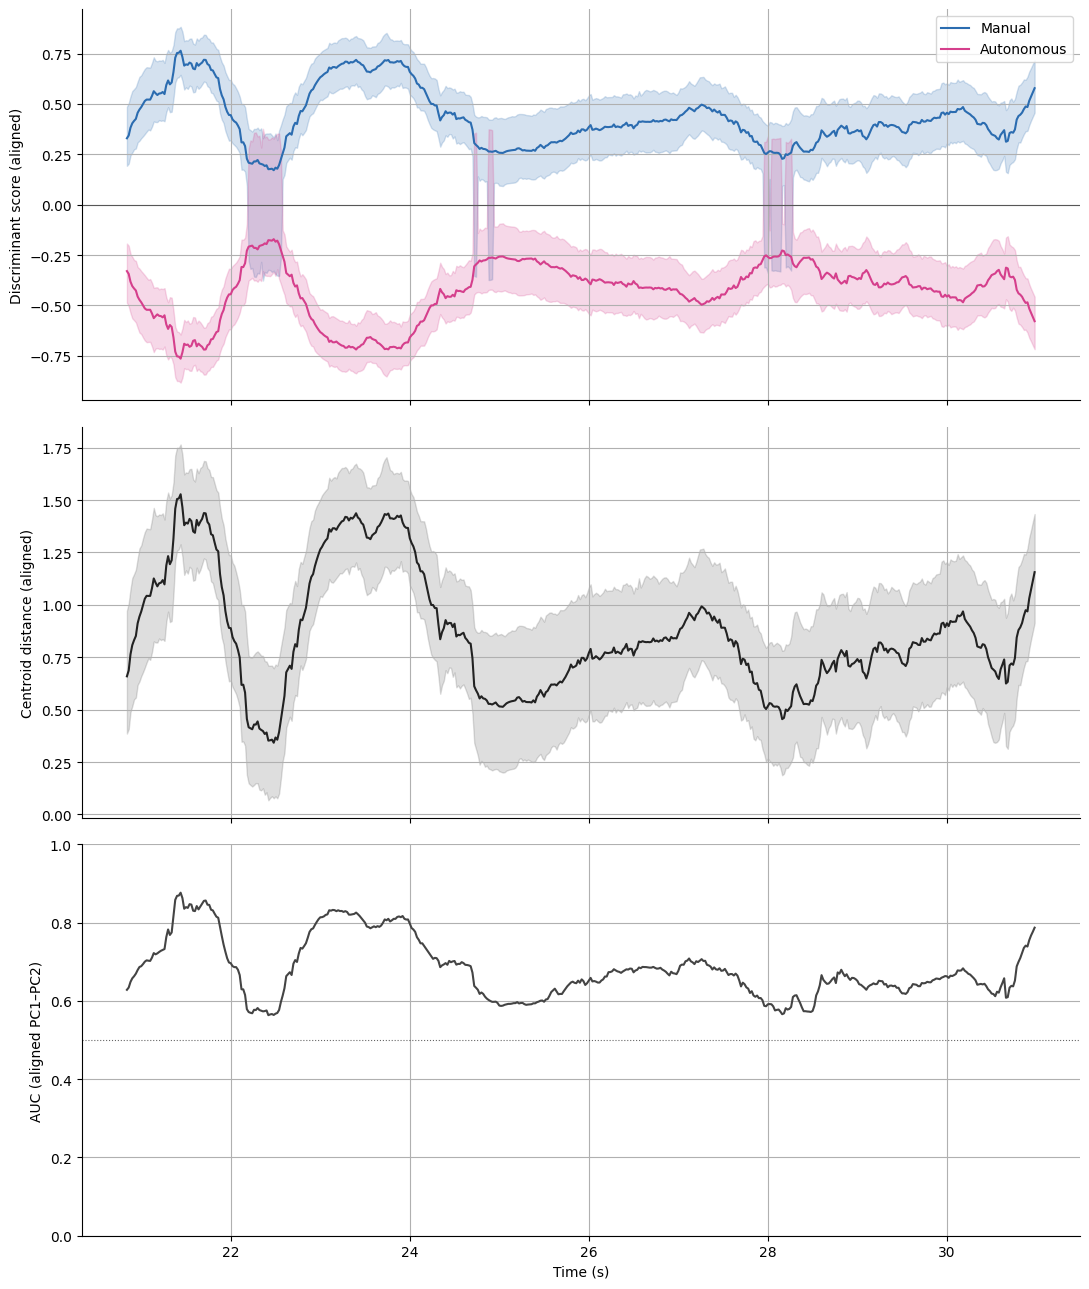

In [9]:
# Recompute metrics with aligned bases (loadings and scores)

aligned_results = []
ref_loadings = None
prev_loadings = None
prev_v = None

for t in unique_times:
    dft = df[df[TIME_COL] == t]
    X = dft[FEATURES].to_numpy(dtype=float)
    y = dft[COND_COL].to_numpy(dtype=int)
    if X.shape[0] < 3:
        continue

    # PCA
    scores_raw, pca, scaler = _compute_pca_scores(X, n_components=2)
    loadings = pca.components_.T  # [n_features x 2]

    # Align loadings to reference and maintain sign continuity
    aligned_loadings, R = _align_basis(loadings, ref_loadings, prev_loadings)

    # Rotate scores with same transform
    scores = scores_raw @ R

    # Discriminant metrics
    v, m, s, s0, s1, dist = _compute_discriminant(scores, y, prev_v)
    prev_v = v

    cis = _bootstrap_ci_scores(scores, y, BOOTSTRAP_REPS, RANDOM_STATE, prev_v)
    auc = _cv_auc(scores, y, CV_FOLDS)

    aligned_results.append({
        "Time": t,
        "Manual_score_mean": s0,
        "Autonomous_score_mean": s1,
        "Manual_score_lo": cis["s0"][0],
        "Manual_score_hi": cis["s0"][1],
        "Autonomous_score_lo": cis["s1"][0],
        "Autonomous_score_hi": cis["s1"][1],
        "CentroidDistance": dist,
        "CentroidDistance_lo": cis["dist"][0],
        "CentroidDistance_hi": cis["dist"][1],
        "AUC": auc,
    })

    # Update references for next timestamp
    if ref_loadings is None:
        ref_loadings = aligned_loadings.copy()
    prev_loadings = aligned_loadings.copy()

aligned_df = pd.DataFrame(aligned_results).sort_values("Time")
aligned_df.to_csv(OUTPUT_DIR / "timewise_discriminant_metrics_aligned.csv", index=False)

# Plot again using aligned metrics
fig, axes = plt.subplots(3, 1, figsize=(11, 13), sharex=True)
ax = axes[0]
ax.plot(aligned_df["Time"], aligned_df["Manual_score_mean"], color="#2b6cb0", label="Manual")
ax.fill_between(aligned_df["Time"], aligned_df["Manual_score_lo"], aligned_df["Manual_score_hi"], color="#2b6cb0", alpha=0.2)
ax.plot(aligned_df["Time"], aligned_df["Autonomous_score_mean"], color="#d53f8c", label="Autonomous")
ax.fill_between(aligned_df["Time"], aligned_df["Autonomous_score_lo"], aligned_df["Autonomous_score_hi"], color="#d53f8c", alpha=0.2)
ax.axhline(0, color="k", lw=0.8, alpha=0.5)
ax.set_ylabel("Discriminant score (aligned)")
ax.legend(loc="upper right")

ax = axes[1]
ax.plot(aligned_df["Time"], aligned_df["CentroidDistance"], color="#222")
ax.fill_between(aligned_df["Time"], aligned_df["CentroidDistance_lo"], aligned_df["CentroidDistance_hi"], color="#222", alpha=0.15)
ax.set_ylabel("Centroid distance (aligned)")

ax = axes[2]
ax.plot(aligned_df["Time"], aligned_df["AUC"], color="#444")
ax.set_ylabel("AUC (aligned PC1–PC2)")
ax.set_xlabel("Time (s)")
ax.set_ylim(0.0, 1.0)
ax.axhline(0.5, color="k", lw=0.8, ls=":", alpha=0.6)

if HAZARD_ONSET is not None:
    for ax in axes:
        ax.axvline(HAZARD_ONSET, color="orangered", lw=1.2, ls="--")
        ax.text(HAZARD_ONSET, ax.get_ylim()[1], " Hazard onset", color="orangered", va="top")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "timewise_discriminant_panels_aligned.png", dpi=200)
print("Saved:", OUTPUT_DIR / "timewise_discriminant_panels_aligned.png")
fig.show()
